# <div style="text-align:center; color:Black; font-weight:bold;">Escalar y Transformar Variables Continuas</div>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Escalamiento de Datos</b><br>
</div>

Se utiliza el Escalamiento Robusto (Robust Scaling), debido a los valores atípicos presentes en la variable precio


In [1]:
# Uso de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans


In [2]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,4)

# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Crear dataset
df = pd.read_csv("../datos/dataset_depurado_sin_duplicados.csv", sep=";")

<Figure size 1200x600 with 0 Axes>

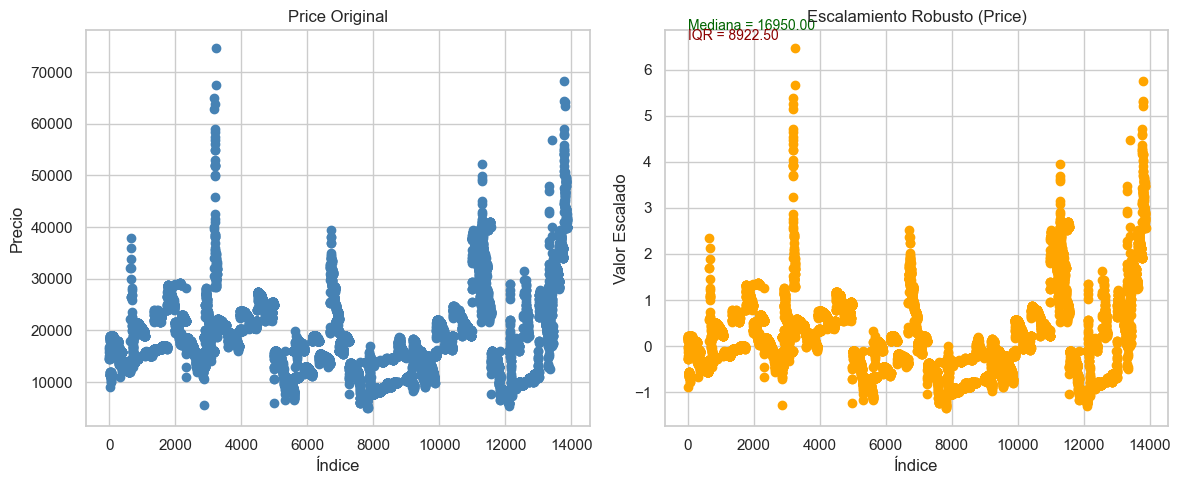

In [3]:
# Extraer columna 'Price' del DataFrame
datos = df['price'].values.reshape(-1, 1)  

# Escalamiento Robusto
scaler = RobustScaler()
datos_robustos = scaler.fit_transform(datos)

# Preparar datos para graficar
indices = np.arange(1, len(datos) + 1)
valores_originales = datos.flatten()
valores_escalados = datos_robustos.flatten()

# Obtener mediana e IQR
q1 = np.percentile(valores_originales, 25)
q3 = np.percentile(valores_originales, 75)
iqr = q3 - q1
mediana = np.median(valores_originales)

# Crear figura
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Datos originales
axs[0].scatter(indices, valores_originales, color='steelblue')
axs[0].set_title('Price Original')
axs[0].set_xlabel('Índice')
axs[0].set_ylabel('Precio')
axs[0].grid(True)


# Gráfico 2: Datos escalados
axs[1].scatter(indices, valores_escalados, color='orange')
axs[1].set_title('Escalamiento Robusto (Price)')
axs[1].set_xlabel('Índice')
axs[1].set_ylabel('Valor Escalado')
axs[1].grid(True)


# Anotaciones
axs[1].text(1, max(valores_escalados) + 0.4, f'Mediana = {mediana:.2f}', fontsize=10, color='darkgreen')
axs[1].text(1, max(valores_escalados) + 0.2, f'IQR = {iqr:.2f}', fontsize=10, color='darkred')

plt.tight_layout()
plt.show()

### <span style="color:Black;"><strong>Interpretación</strong></span>

- El escalamiento robusto preserva la forma de los datos sin que los outliers distorsionen el rango.
- A diferencia de la estandarización tradicional, este método no se ve afectado por la presencia de **outliers**, lo que lo hace especialmente útil cuando los datos presentan distribuciones sesgadas o colas largas a la derecha como es el caso de la variable de estudio el precio.


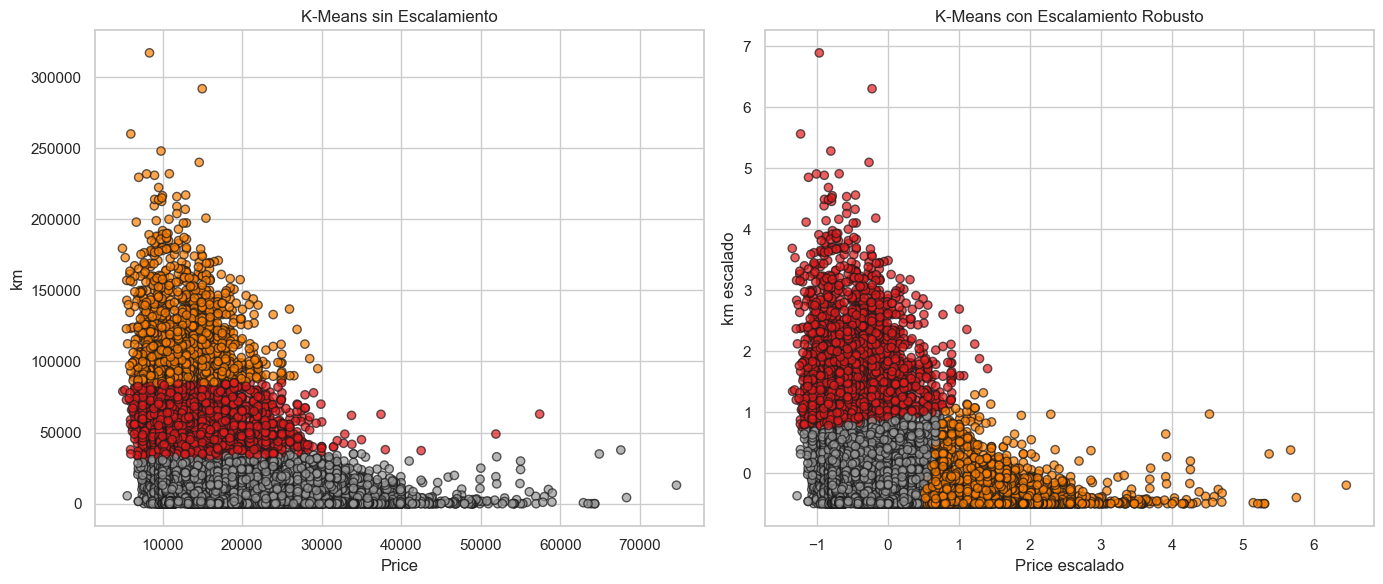

In [4]:
# Extraer columnas reales del DataFrame
X = df[['price', 'km']].values  

# K-Means sin escalamiento
kmeans_raw = KMeans(n_clusters=3, random_state=42)
labels_raw = kmeans_raw.fit_predict(X)

# Escalamiento robusto
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# K-Means con escalamiento robusto
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

# Visualización
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Sin escalamiento
axs[0].scatter(X[:, 0], X[:, 1], c=labels_raw, cmap='Set1', edgecolor='k', alpha=0.7)
axs[0].set_title('K-Means sin Escalamiento')
axs[0].set_xlabel('Price')
axs[0].set_ylabel('km')
axs[0].grid(True)

# Con escalamiento robusto
axs[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_scaled, cmap='Set1', edgecolor='k', alpha=0.7)
axs[1].set_title('K-Means con Escalamiento Robusto')
axs[1].set_xlabel('Price escalado')
axs[1].set_ylabel('km escalado')
axs[1].grid(True)

plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>

Como se observa los clúster conservar la distribución original

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Trasformación de datos</b><br>
</div>

Se elige la transformación logarítmica porque es una técnica clásica utilizada para reducir la asimetría positiva (sesgo a la derecha) en distribuciones donde existen valores muy grandes en comparación con el resto de los datos. En la base de datos todas las variables continuas tienen sesgo a la derecha.

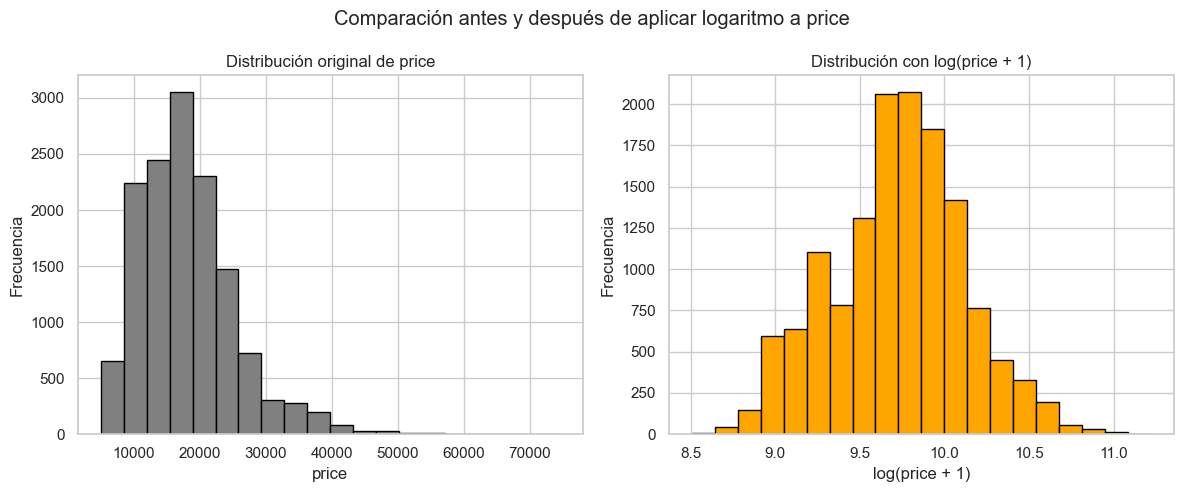

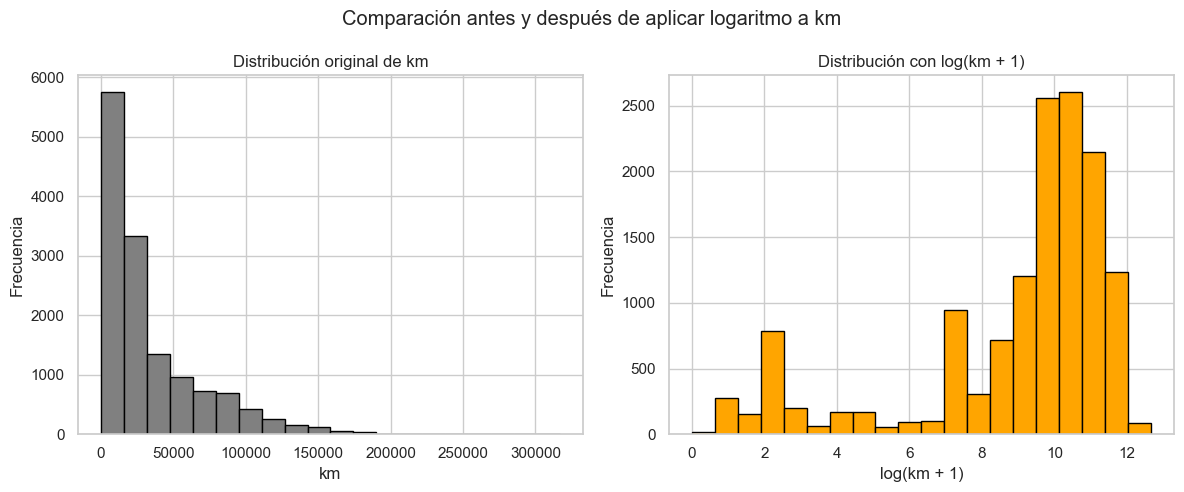

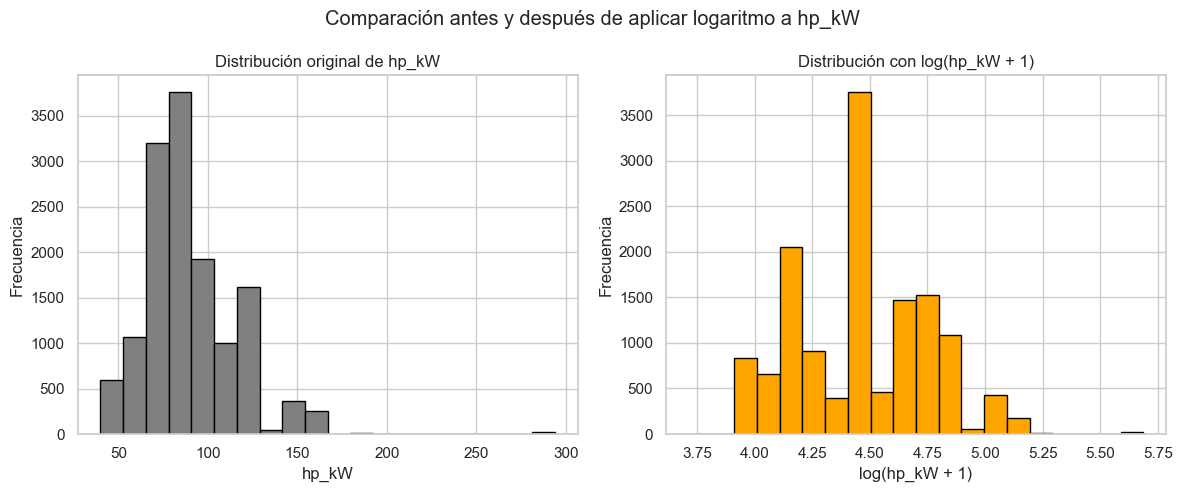

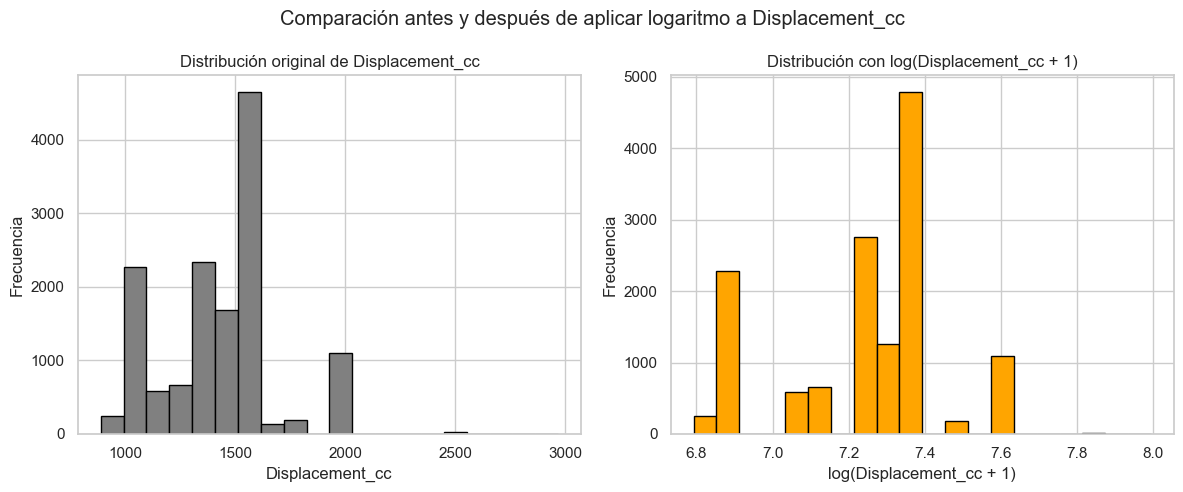

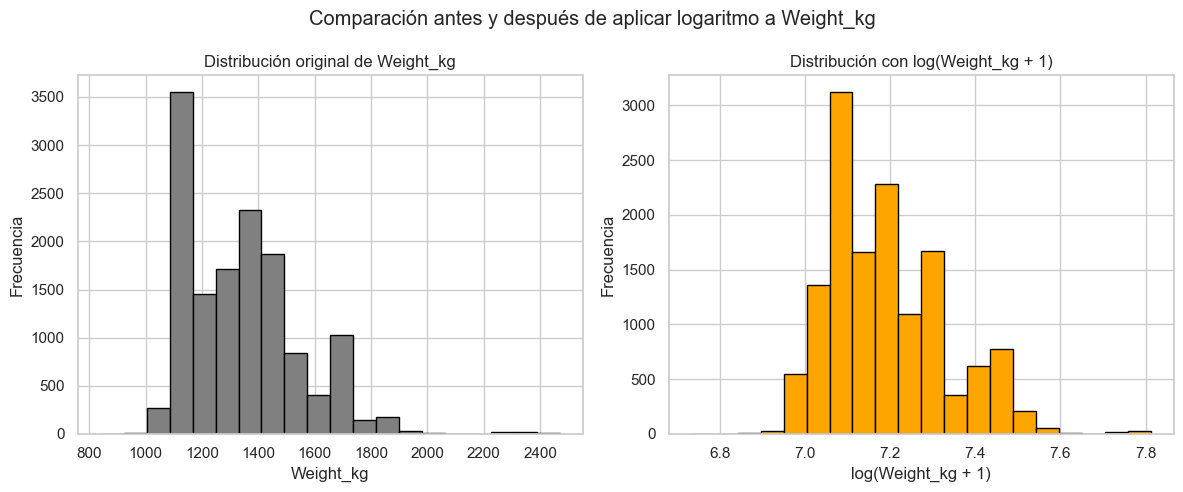

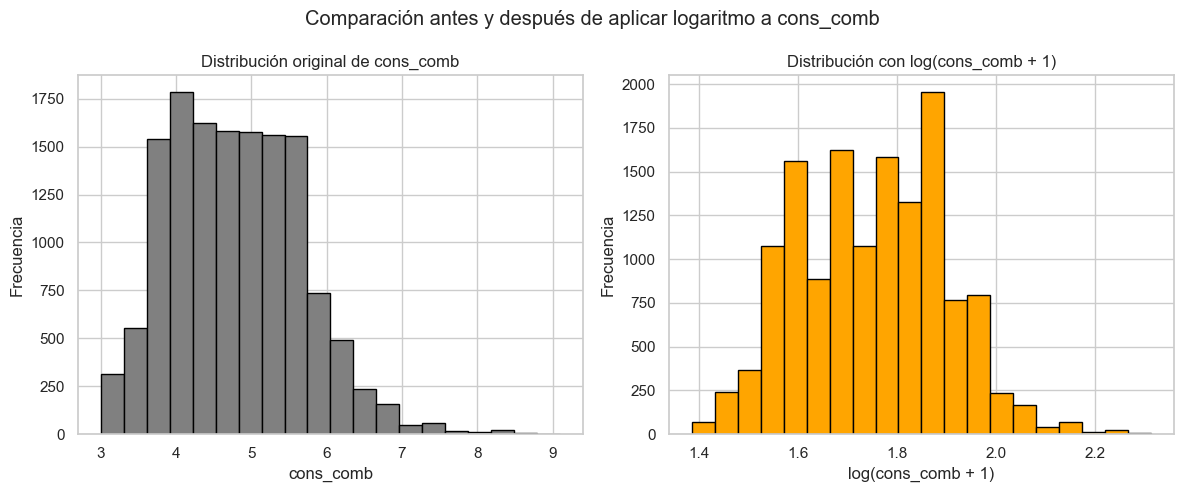

In [5]:
# Lista de variables continuas
variables = ['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']

# Crear figuras
for var in variables:
    
    # Extraer datos
    x = df[var].dropna().values
    
    # Transformación log (se suma 1 para evitar problemas con ceros)
    x_log = np.log(x + 1)

    # Crear gráfica
    plt.figure(figsize=(12, 5))

    # Histograma original
    plt.subplot(1, 2, 1)
    plt.hist(x, bins=20, color='gray', edgecolor='black')
    plt.title(f'Distribución original de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

    # Histograma transformado
    plt.subplot(1, 2, 2)
    plt.hist(x_log, bins=20, color='orange', edgecolor='black')
    plt.title(f'Distribución con log({var} + 1)')
    plt.xlabel(f'log({var} + 1)')
    plt.ylabel('Frecuencia')

    plt.suptitle(f'Comparación antes y después de aplicar logaritmo a {var}')
    plt.tight_layout()
    plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>

Tras aplicar la transformación log(x + 1) a las variables continuas del conjunto de datos, se observa una mejora general en la forma de las distribuciones. En casi todas las variables, la transformación reduce la asimetría positiva, comprime los valores extremos y acerca la distribución a una forma más simétrica. Esto favorece los supuestos de normalidad utilizados en varios métodos estadísticos y mejora el comportamiento de los modelos predictivos.

La transformación logarítmica fue efectiva para todas las variables continuas:

- Reduce asimetría y curtosis
- Comprime valores extremos
- Mejora la forma de las distribuciones
- Prepara mejor los datos para PCA, regresión y clustering
- Reduce la influencia de outliers sin eliminarlos